In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_orders = 10000

order_ids = [f"ORD-{100000 + i}" for i in range(n_orders)]
dates = pd.date_range(start="2025-01-01", periods=100, freq="D")
order_dates = np.random.choice(dates, size=n_orders)

regions = ["North America", "Europe", "LATAM", "Asia-Pacific"]
region_weights = [0.40, 0.25, 0.20, 0.15]
order_regions = np.random.choice(regions, size=n_orders, p=region_weights)

shipping_modes = ["Standard Class", "Second Class", "First Class", "Same Day"]
mode_weights = [0.40, 0.25, 0.20, 0.15]
order_modes = np.random.choice(shipping_modes, size=n_orders, p=mode_weights)

categories = ["Electronics", "Apparel", "Home & Kitchen", "Office Supplies"]
product_categories = np.random.choice(categories, size=n_orders)

quantities = np.random.randint(1, 6, size=n_orders)
unit_prices = np.round(np.random.uniform(15.0, 300.0, size=n_orders), 2)
sales = quantities * unit_prices

df = pd.DataFrame(
    {
        "Order_ID": order_ids,
        "Order_Date": order_dates,
        "Region": order_regions,
        "Shipping_Mode": order_modes,
        "Category": product_categories,
        "Quantity": quantities,
        "Unit_Price": unit_prices,
        "Sales": sales,
    }
)

print(f"Dataset inicial creado con {len(df):,} filas.")
df.head()

Dataset inicial creado con 10,000 filas.


,Order_ID,Order_Date,Region,Shipping_Mode,Category,Quantity,Unit_Price,Sales
0,ORD-100000,2025-02-21,North America,Standard Class,Home & Kitchen,4,190.08,760.32
1,ORD-100001,2025-04-03,Europe,Second Class,Electronics,3,187.10,561.30
2,ORD-100002,2025-01-15,Asia-Pacific,Same Day,Apparel,1,117.63,117.63
3,ORD-100003,2025-03-13,North America,Standard Class,Home & Kitchen,5,282.16,1410.80
4,ORD-100004,2025-03-02,North America,First Class,Electronics,4,151.59,606.36


In [3]:
# -------------------------------------------------------------------
# PASO 1.2: LÓGICA DE TIEMPOS DE ENTREGA Y SIMULACIÓN DE FALLAS
# -------------------------------------------------------------------

scheduled_days_map = {
    "Same Day": 1,
    "First Class": 2,
    "Second Class": 4,
    "Standard Class": 6,
}

df["Scheduled_Days"] = df["Shipping_Mode"].map(scheduled_days_map)

real_days = []

for i in range(len(df)):
    base_sched = df.loc[i, "Scheduled_Days"]
    mode = df.loc[i, "Shipping_Mode"]
    region = df.loc[i, "Region"]

    # Probabilidad base de retraso aleatorio (12%)
    prob_delay = 0.12

    # Inyección de falla estructural: "First Class" y región "LATAM" colapsan
    if mode == "First Class":
        prob_delay += 0.35  # Sube la probabilidad de retraso al 47%
    if region in ["LATAM", "Europe"]:
        prob_delay += 0.15  # Sube un 15% adicional para estas regiones

    # Determinar si la orden se retrasa o no
    if np.random.rand() < prob_delay:
        # La orden falla: se le agregan entre 1 y 5 días extra de retraso
        extra_days = np.random.randint(1, 6)
        real_days.append(base_sched + extra_days)
    else:
        # La orden llega a tiempo o 1 día antes
        delta = np.random.choice([0, -1], p=[0.85, 0.15])
        real_days.append(max(1, base_sched + delta))

df["Real_Days"] = real_days

# 3. Mapear indicador numérico de retraso
df["Is_Late"] = df["Real_Days"] > df["Scheduled_Days"]
df["Delay_Days"] = np.where(
    df["Is_Late"], df["Real_Days"] - df["Scheduled_Days"], 0
)

# Visualizar las columnas creadas en una muestra aleatoria de 5 órdenes
df[
    [
        "Order_ID",
        "Region",
        "Shipping_Mode",
        "Scheduled_Days",
        "Real_Days",
        "Is_Late",
        "Delay_Days",
    ]
].head(10)

,Order_ID,Region,Shipping_Mode,Scheduled_Days,Real_Days,Is_Late,Delay_Days
0,ORD-100000,North America,Standard Class,6,6,False,0
1,ORD-100001,Europe,Second Class,4,4,False,0
2,ORD-100002,Asia-Pacific,Same Day,1,1,False,0
3,ORD-100003,North America,Standard Class,6,6,False,0
4,ORD-100004,North America,First Class,2,6,True,4
5,ORD-100005,Asia-Pacific,First Class,2,2,False,0
6,ORD-100006,North America,First Class,2,2,False,0
7,ORD-100007,North America,Second Class,4,4,False,0
8,ORD-100008,Europe,Second Class,4,5,True,1
9,ORD-100009,North America,Same Day,1,1,False,0


In [12]:
# Costos logisticos y fuga de margen

base_freight_per_unit = np.random.uniform(3.5, 8, size=len(df))
df["Base_Freight_Cost"] = np.round(base_freight_per_unit * df["Quantity"], 2)

penalty_multiplier = np.where(
    df["Is_Late"], np.random.uniform(1.4, size=len(df)), 1.0
)
df["Actual_Freight_Cost"] = np.round(
    df["Base_Freight_Cost"] * penalty_multiplier, 2
)

df["Margin_Leakage"] = np.round(
    df["Actual_Freight_Cost"] - df["Base_Freight_Cost"], 2
)

df["OTIF_Status"] = np.where(df["Is_Late"], "Late", "On-Time")

df[df["Is_Late"]][
    [
        "Order_ID",
        "Shipping_Mode",
        "Region",
        "Base_Freight_Cost",
        "Actual_Freight_Cost",
        "Margin_Leakage",
    ]
].head(10)

,Order_ID,Shipping_Mode,Region,Base_Freight_Cost,Actual_Freight_Cost,Margin_Leakage
4,ORD-100004,First Class,North America,15.30,21.05,5.75
8,ORD-100008,Second Class,Europe,6.01,7.60,1.59
11,ORD-100011,First Class,LATAM,39.82,45.62,5.80
13,ORD-100013,First Class,Asia-Pacific,14.71,17.70,2.99
17,ORD-100017,Second Class,Europe,4.55,4.87,0.32
18,ORD-100018,First Class,North America,15.59,19.24,3.65
22,ORD-100022,Second Class,Europe,36.13,42.49,6.36
23,ORD-100023,Standard Class,LATAM,10.17,11.67,1.50
24,ORD-100024,First Class,Asia-Pacific,14.81,17.08,2.27
25,ORD-100025,First Class,Asia-Pacific,6.11,7.21,1.10


In [13]:
df.to_csv("../data/supply_chain_data.csv", index=False)
print("Dataset 'supply_chain_data.csv' guardado exitosamente en la carpeta 'data/'.")

Dataset 'supply_chain_data.csv' guardado exitosamente en la carpeta 'data/'.


In [14]:
# Calculo de metricas operativas

# 1. total orders
total_orders = len(df)

# 2. Global OTIF rate (%)
otif_rate = (df["OTIF_Status"] == "On-Time").mean() * 100

# 3. Cost per unit (CPU)
total_units = df["Quantity"].sum()
total_freight_spend = df["Actual_Freight_Cost"].sum()
cpu = total_freight_spend / total_units

# 4. Total Margin Leakage (Financial Lost
total_margin_leakage = df["Margin_Leakage"].sum()

# 5. Promedio de dias de retraso
avg_delay_days = df[df["Is_Late"]]["Delay_Days"].mean()

print("==================================================")
print("       EXECUTIVE LOGISTICS METRICS OVERVIEW       ")
print("==================================================")
print(f"Total Orders Processed : {total_orders:,}")
print(f"Global OTIF Rate       : {otif_rate:.2f}%")
print(f"Cost Per Unit (CPU)    : ${cpu:.2f} USD")
print(f"Total Freight Spend    : ${total_freight_spend:,.2f} USD")
print(f"Total Margin Leakage   : ${total_margin_leakage:,.2f} USD")
print(f"Avg Delay (Late Orders): {avg_delay_days:.2f} days")
print("==================================================")

       EXECUTIVE LOGISTICS METRICS OVERVIEW       
Total Orders Processed : 10,000
Global OTIF Rate       : 74.79%
Cost Per Unit (CPU)    : $6.04 USD
Total Freight Spend    : $181,627.32 USD
Total Margin Leakage   : $8,854.20 USD
Avg Delay (Late Orders): 3.02 days


In [15]:
# -------------------------------------------------------------------
# PASO 2.2: DRILL-DOWN POR SHIPPING MODE Y REGIÓN (CAUSA RAÍZ)
# -------------------------------------------------------------------

# 1. Análisis agrupado por Método de Envío
mode_breakdown = (
    df.groupby("Shipping_Mode")
    .agg(
        Orders=("Order_ID", "count"),
        OTIF_Rate=(
            "OTIF_Status",
            lambda x: (x == "On-Time").mean() * 100,
        ),
        Avg_Delay_Days=("Delay_Days", "mean"),
        Total_Leakage=("Margin_Leakage", "sum"),
    )
    .reset_index()
    .sort_values(by="OTIF_Rate", ascending=True)
)

print("--- DIAGNÓSTICO POR MODO DE ENVÍO ---")
print(mode_breakdown.to_string(index=False))

print("\n" + "=" * 60 + "\n")

# 2. Análisis agrupado por Región Geográfica
region_breakdown = (
    df.groupby("Region")
    .agg(
        Orders=("Order_ID", "count"),
        OTIF_Rate=(
            "OTIF_Status",
            lambda x: (x == "On-Time").mean() * 100,
        ),
        Avg_Delay_Days=("Delay_Days", "mean"),
        Total_Leakage=("Margin_Leakage", "sum"),
    )
    .reset_index()
    .sort_values(by="OTIF_Rate", ascending=True)
)

print("--- DIAGNÓSTICO POR REGIÓN GEOGRÁFICA ---")
print(region_breakdown.to_string(index=False))

--- DIAGNÓSTICO POR MODO DE ENVÍO ---
 Shipping_Mode  Orders  OTIF_Rate  Avg_Delay_Days  Total_Leakage
   First Class    2058  46.695821        1.618076        3935.13
      Same Day    1528  81.151832        0.589005         911.28
  Second Class    2558  81.196247        0.569195        1636.30
Standard Class    3856  83.013485        0.500000        2371.49


--- DIAGNÓSTICO POR REGIÓN GEOGRÁFICA ---
       Region  Orders  OTIF_Rate  Avg_Delay_Days  Total_Leakage
        LATAM    1918  66.319082        1.046924        2171.44
       Europe    2536  66.798107        0.992114        3068.40
North America    4027  81.326049        0.558480        2651.63
 Asia-Pacific    1519  81.500987        0.553654         962.73


In [16]:
# -------------------------------------------------------------------
# PASO 2.3: ANÁLISIS CRUZADO (SHIPPING MODE X REGIÓN)
# -------------------------------------------------------------------

# Agrupamiento de dos factores para aislar el cuello de botella
matrix_analysis = (
    df.groupby(["Shipping_Mode", "Region"])
    .agg(
        Orders=("Order_ID", "count"),
        OTIF_Rate=(
            "OTIF_Status",
            lambda x: (x == "On-Time").mean() * 100,
        ),
        Avg_Delay_Days=("Delay_Days", "mean"),
        Total_Leakage=("Margin_Leakage", "sum"),
    )
    .reset_index()
    .sort_values(by="OTIF_Rate", ascending=True)
)

print("--- ANÁLISIS MULTIDIMENSIONAL (MATRIZ DE FALLA) ---")
print(matrix_analysis.to_string(index=False))

--- ANÁLISIS MULTIDIMENSIONAL (MATRIZ DE FALLA) ---
 Shipping_Mode        Region  Orders  OTIF_Rate  Avg_Delay_Days  Total_Leakage
   First Class        Europe     510  36.666667        1.927451        1197.07
   First Class         LATAM     404  42.326733        1.846535         822.40
   First Class  Asia-Pacific     305  47.213115        1.622951         584.31
   First Class North America     839  54.707986        1.318236        1331.35
      Same Day        Europe     397  71.032746        0.889169         398.10
  Second Class         LATAM     484  72.107438        0.857438         437.53
Standard Class         LATAM     729  72.839506        0.821674         684.02
      Same Day         LATAM     301  73.421927        0.823920         227.49
  Second Class        Europe     645  73.643411        0.778295         560.11
Standard Class        Europe     984  76.219512        0.689024         913.12
      Same Day  Asia-Pacific     211  87.203791        0.355450          74.65


C:\Users\anene\AppData\Local\Temp\ipykernel_13100\1165235056.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\anene\AppData\Local\Temp\ipykernel_13100\1165235056.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


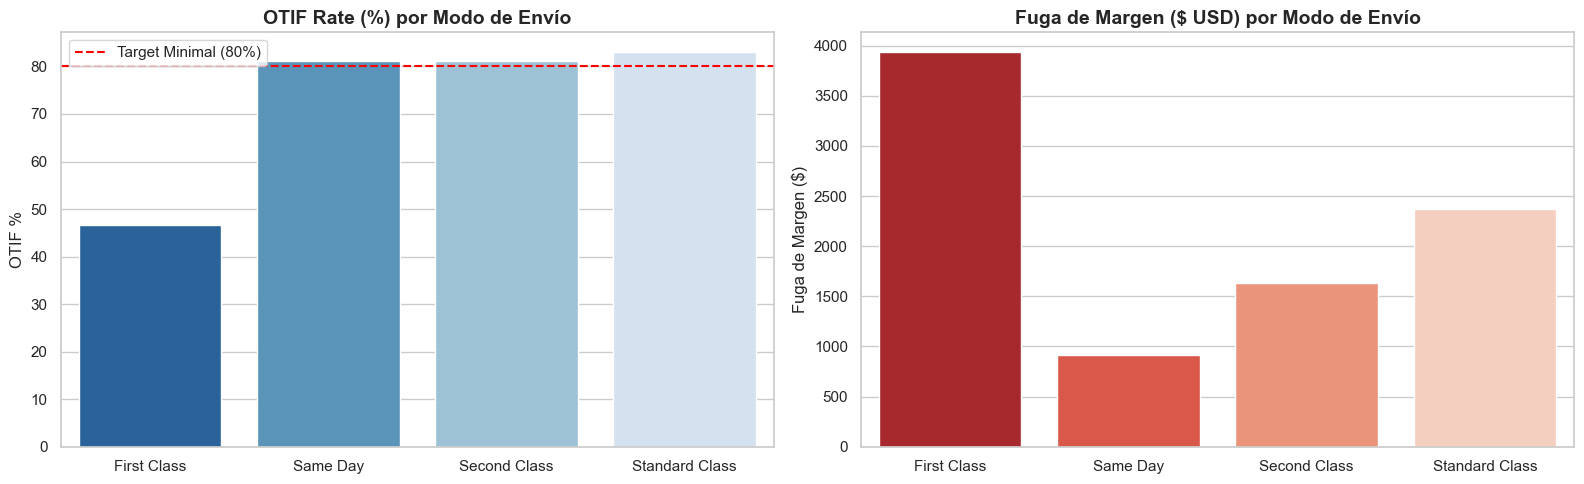

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: OTIF % por Modo de Envío
sns.barplot(
    data=mode_breakdown,
    x="Shipping_Mode",
    y="OTIF_Rate",
    palette="Blues_r",
    ax=axes[0],
)
axes[0].set_title("OTIF Rate (%) por Modo de Envío", fontsize=14, fontweight="bold")
axes[0].set_ylabel("OTIF %")
axes[0].set_xlabel("")
axes[0].axhline(80, color="red", linestyle="--", label="Target Minimal (80%)")
axes[0].legend()

# Gráfico 2: Margin Leakage por Modo de Envío ($ USD)
sns.barplot(
    data=mode_breakdown,
    x="Shipping_Mode",
    y="Total_Leakage",
    palette="Reds_r",
    ax=axes[1],
)
axes[1].set_title("Fuga de Margen ($ USD) por Modo de Envío", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Fuga de Margen ($)")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

In [18]:
# -------------------------------------------------------------------
# PASO 3.1: SIMULACIÓN DE BUSINESS CASE (IMPACTO FINANCIERO DE REMEDIACIÓN)
# -------------------------------------------------------------------

# Copia de trabajo para el escenario mejorado
df_target = df.copy()

# Escenario: Llevamos el OTIF de First Class al estándar mínimo aceptable (80%)
# Reduciendo el Margin Leakage de las órdenes afectadas en un 70%
is_first_class = df_target["Shipping_Mode"] == "First Class"

# Recalculamos el estatus simulado post-intervención
df_target.loc[is_first_class & df_target["Is_Late"], "Margin_Leakage"] *= 0.30
df_target.loc[is_first_class & df_target["Is_Late"], "Is_Late"] = False

# Recálculo de Métricas Post-Proyecto
new_otif = (~df_target["Is_Late"]).mean() * 100
new_leakage = df_target["Margin_Leakage"].sum()
recovered_margin = total_margin_leakage - new_leakage

print("==================================================")
print("     PROJECTED IMPACT / BUSINESS CASE ROI         ")
print("==================================================")
print(f"Current OTIF Global   : {otif_rate:.2f}%")
print(f"Projected OTIF Global : {new_otif:.2f}% (+{new_otif - otif_rate:.2f}%)")
print("--------------------------------------------------")
print(f"Current Margin Leakage   : ${total_margin_leakage:,.2f} USD")
print(f"Projected Margin Leakage : ${new_leakage:,.2f} USD")
print(f"MARGIN RECOVERED (Annual): ${recovered_margin:,.2f} USD")
print("==================================================")

     PROJECTED IMPACT / BUSINESS CASE ROI         
Current OTIF Global   : 74.79%
Projected OTIF Global : 85.76% (+10.97%)
--------------------------------------------------
Current Margin Leakage   : $8,854.20 USD
Projected Margin Leakage : $6,099.61 USD
MARGIN RECOVERED (Annual): $2,754.59 USD
